# Task 3: Resume / Candidate Screening System
**CIN:** FIT/FEB26/ML5800
[cite_start]**Objective:** Automatically screen and rank resumes based on job role requirements[cite: 97].
[cite_start]**Skills Gained:** Text analysis, feature extraction, resume scoring, ranking models[cite: 99].

In [6]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

data = {
    'Candidate_Name': ['Alice Smith', 'Bob Jones', 'Charlie Brown'],
    'Resume_Text': [
        'Data Scientist with Python, Machine Learning, and SQL experience.',
        'Web Developer expert in HTML, CSS, JavaScript, and React.',
        'ML Engineer specialized in NLP, Python, and Predictive Modeling.'
    ]
}
df = pd.DataFrame(data)
job_description = "Looking for a Machine Learning professional with Python and NLP skills."

tfidf = TfidfVectorizer(stop_words='english')
all_texts = df['Resume_Text'].tolist() + [job_description]
tfidf_matrix = tfidf.fit_transform(all_texts)

scores = cosine_similarity(tfidf_matrix[:-1], tfidf_matrix[-1:])
df['Match_Score'] = (scores.flatten() * 100).round(2)

ranked_candidates = df.sort_values(by='Match_Score', ascending=False)
print(ranked_candidates[['Candidate_Name', 'Match_Score']])

  Candidate_Name  Match_Score
0    Alice Smith        30.24
2  Charlie Brown        18.25
1      Bob Jones         0.00


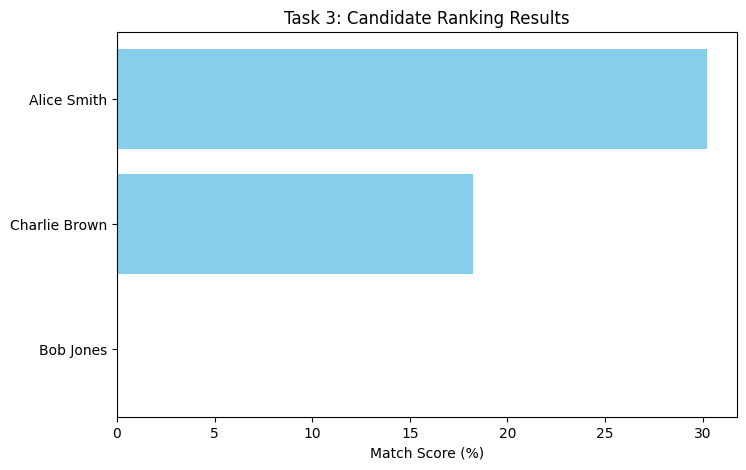

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(ranked_candidates['Candidate_Name'], ranked_candidates['Match_Score'], color='skyblue')
plt.xlabel('Match Score (%)')
plt.title('Task 3: Candidate Ranking Results')
plt.gca().invert_yaxis() 
plt.show()